# Cómo filtrar mal un ECG simula una isquemia

Este notebook demuestra, con números, que una decisión de procesamiento de señales
aparentemente inocua —elegir la frecuencia de corte de un filtro paso-alto— puede
introducir en el ECG un desnivel del segmento ST mayor que el umbral clínico usado
para diagnosticar isquemia miocárdica.

**Requisitos:** `numpy`, `scipy`, `matplotlib`.

---

## 1. Por qué señal sintética y no un registro real

Para medir la distorsión que introduce un filtro hace falta conocer el valor verdadero
del segmento ST. En un registro real ese valor no se conoce: solo se puede comparar
un filtrado contra otro, nunca contra la verdad.

Por eso generamos un ECG sintético con **segmento ST exactamente isoeléctrico (0 µV)**.
Cualquier desnivel que aparezca después de filtrar es, por construcción, un artefacto
del filtro.

> Al final del notebook se indica cómo repetir el experimento sobre registros reales
> de PhysioNet.

In [1]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 10, 'figure.dpi': 120, 'axes.grid': True,
                     'grid.alpha': 0.25, 'axes.spines.top': False,
                     'axes.spines.right': False})

FS = 360           # Hz, igual que MIT-BIH Arrhythmia
ROJO, VERDE = '#c0392b', '#0b6e5f'

## 2. Generador de ECG

Modelamos cada onda del complejo PQRST como una gaussiana. Es el enfoque clásico
de McSharry et al. (2003), simplificado: suficiente para que la morfología sea
realista en amplitud y duración, que es lo que importa aquí.

| Onda | Centro respecto a R | Amplitud | Sigma |
|---|---|---|---|
| P | −200 ms | +0.15 mV | 25 ms |
| Q | −35 ms | −0.10 mV | 8 ms |
| R | 0 ms | +1.10 mV | 10 ms |
| S | +35 ms | −0.25 mV | 10 ms |
| T | +280 ms | +0.30 mV | 45 ms |

Entre el final de S y el inicio de T no sumamos nada: **el segmento ST queda plano en cero.**

In [2]:
def ecg_sintetico(fs=FS, dur=10.0, hr=60.0, amp_r=1.10):
    """ECG sintético por suma de gaussianas, con segmento ST isoeléctrico.

    amp_r escala toda la señal para simular derivaciones con QRS mayor
    (p. ej. V4, donde 2.0-2.5 mV es normal).

    Devuelve (t, señal_mV, tiempos_de_pico_R).
    """
    n = int(fs * dur)
    t = np.arange(n) / fs
    rr = 60.0 / hr
    x = np.zeros(n)

    ondas = [(-0.200,  0.15, 0.025),   # P
             (-0.035, -0.10, 0.008),   # Q
             ( 0.000,  1.10, 0.010),   # R
             ( 0.035, -0.25, 0.010),   # S
             ( 0.280,  0.30, 0.045)]   # T

    picos = []
    for k in range(int(dur / rr) + 2):
        tr = 0.35 + k * rr
        if tr > dur - 0.5:
            break
        picos.append(tr)
        for centro, amp, sigma in ondas:
            x += amp * np.exp(-0.5 * ((t - (tr + centro)) / sigma) ** 2)

    return t, x * (amp_r / 1.10), np.array(picos)

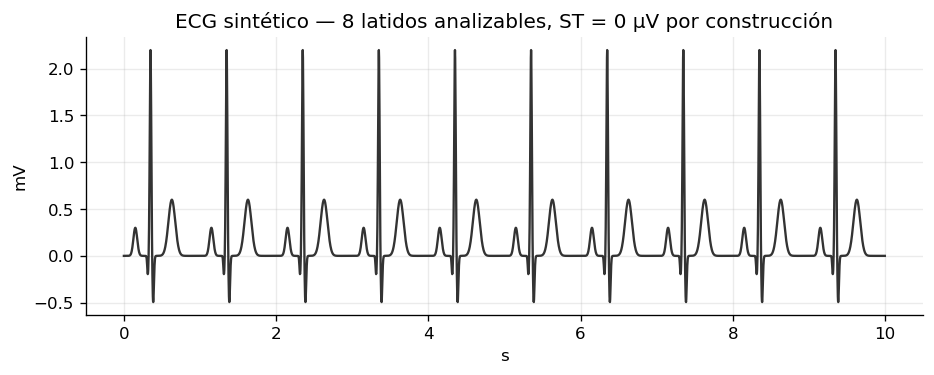

In [3]:
t, ecg, picos = ecg_sintetico(amp_r=2.20)   # amplitud tipo V4
picos = picos[1:-1]                          # descartar latidos de borde

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(t, ecg, color='#333', lw=1.4)
ax.set_xlabel('s'); ax.set_ylabel('mV')
ax.set_title(f'ECG sintético — {len(picos)} latidos analizables, ST = 0 µV por construcción')
plt.show()

## 3. Cómo se mide el nivel del segmento ST

En la práctica clínica el desnivel del ST no se mide contra cero absoluto, sino contra
la **línea base del propio latido**, tomada en el segmento PQ (entre el final de la P
y el inicio del QRS). El nivel ST se lee en el **punto J + 60 ms**, donde J es el final
del complejo QRS.

Esto importa porque un filtro puede desplazar los dos puntos de forma distinta, y es
justamente esa diferencia la que se interpreta como isquemia.

In [5]:
def nivel_st(x, picos, fs=FS, offset=0.060):
    """Desnivel ST en J+offset respecto a la línea base PQ, por latido (en mV)."""
    vals = []
    for tr in picos:
        i = int(tr * fs)
        # línea base: ventana PQ, de -80 a -60 ms antes del pico R
        base = np.mean(x[i - int(0.080 * fs): i - int(0.060 * fs)])
        # punto J aproximado: 40 ms después del pico R
        j = int((tr + 0.040) * fs)
        k = j + int(offset * fs)
        st = np.mean(x[k - 2: k + 3])
        vals.append(st - base)
    return np.array(vals)


def paso_alto(x, fc, fs=FS, orden=2, fase_cero=True):
    """Butterworth paso-alto. fase_cero=True usa filtrado bidireccional."""
    sos = signal.butter(orden, fc, 'highpass', fs=fs, output='sos')
    return signal.sosfiltfilt(sos, x) if fase_cero else signal.sosfilt(sos, x)


print(f'ST de la señal sin filtrar: {nivel_st(ecg, picos).mean()*1000:+.1f} µV')

ST de la señal sin filtrar: +0.3 µV


La medición sobre la señal cruda da esencialmente cero, como debe ser. La herramienta
está calibrada; ahora podemos confiar en lo que mida después de filtrar.

## 4. El experimento

Comparamos dos configuraciones sobre **la misma señal**:

- `butter(4, 0.5, 'high')` + `lfilter` — lo que suele copiarse de tutoriales genéricos
- `butter(2, 0.05, 'high')` + `filtfilt` — la configuración conforme a la norma

In [6]:
malo  = paso_alto(ecg, fc=0.50, orden=4, fase_cero=False)
bueno = paso_alto(ecg, fc=0.05, orden=2, fase_cero=True)

st_malo  = nivel_st(malo,  picos).mean() * 1000
st_bueno = nivel_st(bueno, picos).mean() * 1000

print(f'butter(4, 0.50 Hz) + lfilter   ->  ST = {st_malo:+7.1f} µV')
print(f'butter(2, 0.05 Hz) + filtfilt  ->  ST = {st_bueno:+7.1f} µV')
print()
print(f'Umbral clínico de isquemia significativa: ±100 µV')
print(f'El primer filtro {"SUPERA" if abs(st_malo) > 100 else "no supera"} ese umbral.')

butter(4, 0.50 Hz) + lfilter   ->  ST =  -154.0 µV
butter(2, 0.05 Hz) + filtfilt  ->  ST =    +1.1 µV

Umbral clínico de isquemia significativa: ±100 µV
El primer filtro SUPERA ese umbral.


Una depresión de más de 100 µV es el criterio habitual de desnivel significativo del ST.
El filtro la produjo sobre una señal donde el ST valía exactamente cero.

Ningún paciente, ningún electrodo, ninguna patología: solo la elección de la frecuencia
de corte y del sentido del filtrado.

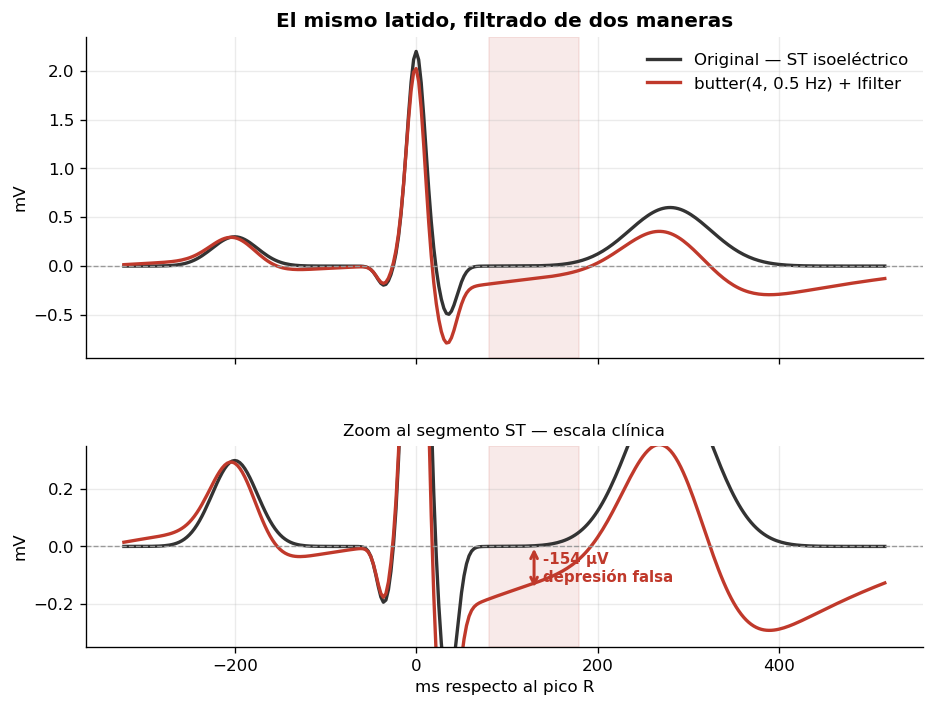

In [7]:
tr = picos[2]
i0, i1 = int((tr - 0.32) * FS), int((tr + 0.52) * FS)
tt = (t[i0:i1] - tr) * 1000

fig, (a1, a2) = plt.subplots(2, 1, figsize=(9, 6.6),
                             gridspec_kw={'height_ratios': [2, 1.25], 'hspace': 0.34})
for ax in (a1, a2):
    ax.plot(tt, ecg[i0:i1],  color='#333', lw=2.0, label='Original — ST isoeléctrico')
    ax.plot(tt, malo[i0:i1], color=ROJO,  lw=2.0, label="butter(4, 0.5 Hz) + lfilter")
    ax.axhline(0, color='#999', lw=0.8, ls='--')
    ax.axvspan(80, 180, color=ROJO, alpha=0.10)

a1.set_ylabel('mV'); a1.legend(loc='upper right', frameon=False); a1.set_xticklabels([])
a1.set_title('El mismo latido, filtrado de dos maneras', fontweight='bold')
a2.set_ylim(-0.35, 0.35); a2.set_xlabel('ms respecto al pico R'); a2.set_ylabel('mV')
a2.set_title('Zoom al segmento ST — escala clínica', fontsize=10)
a2.annotate('', xy=(130, 0.004), xytext=(130, st_malo/1000),
            arrowprops=dict(arrowstyle='<->', color=ROJO, lw=1.8))
a2.text(140, st_malo/2000, f'{st_malo:.0f} µV\ndepresión falsa',
        color=ROJO, fontweight='bold', fontsize=9, va='center')
plt.show()

En el panel superior la diferencia parece menor. En el inferior, a la escala en que
realmente se lee un ECG, es un hallazgo que cambiaría una decisión clínica.

Fíjate también en la onda T: pierde amplitud y aparece un desnivel negativo después
de ella. La distorsión no se limita al ST.

## 5. ¿Cuál es el culpable: la frecuencia o el sentido del filtrado?

Aquí está el matiz que casi ningún tutorial menciona. Barremos la frecuencia de corte
manteniendo el orden, y comparamos filtrado unidireccional contra fase cero.

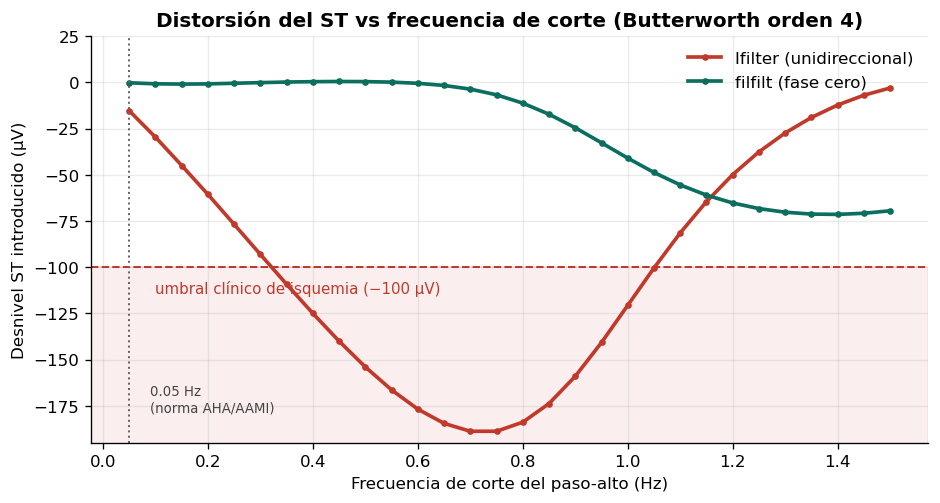

In [13]:
fcs = np.arange(0.05, 1.55, 0.05)
unidir     = [nivel_st(paso_alto(ecg, f, orden=4, fase_cero=False), picos).mean()*1000 for f in fcs]
bidireccional = [nivel_st(paso_alto(ecg, f, orden=4, fase_cero=True),  picos).mean()*1000 for f in fcs]

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.axhspan(-100, -300, color=ROJO, alpha=0.08)
ax.axhline(-100, color=ROJO, ls='--', lw=1.2)
ax.text(0.10, -107, 'umbral clínico de isquemia (−100 µV)', va='top', color=ROJO, fontsize=9)
ax.plot(fcs, unidir,        color=ROJO,  lw=2.2, marker='o', ms=3, label='Ifilter (unidireccional)')
ax.plot(fcs, bidireccional, color=VERDE, lw=2.2, marker='o', ms=3, label='filfilt (fase cero)')
ax.axvline(0.05, color='#666', ls=':', lw=1.2)
ax.text(0.09, -178, '0.05 Hz\n(norma AHA/AAMI)', fontsize=8, color='#444')
ax.set_xlabel('Frecuencia de corte del paso-alto (Hz)')
ax.set_ylabel('Desnivel ST introducido (µV)')
ax.set_title('Distorsión del ST vs frecuencia de corte (Butterworth orden 4)', fontweight='bold')
ax.legend(loc='upper right', frameon=False); ax.set_ylim(-195, 25)
plt.show()

La curva roja cruza el umbral clínico alrededor de **0.3 Hz** y llega a casi −190 µV.
La verde se mantiene plana hasta cerca de 0.8 Hz.

**La frecuencia de corte no es el problema por sí sola: lo es en combinación con la
no linealidad de fase.** Un filtro IIR unidireccional retrasa cada componente de
frecuencia una cantidad distinta. Como el segmento ST se reconstruye a partir de la
suma de los primeros armónicos del latido, desfasarlos entre sí desplaza su nivel.
Aplicar el mismo filtro hacia adelante y hacia atrás cancela ese desfase.

Esto explica la aparente contradicción de la norma AHA, que fija 0.05 Hz para filtros
convencionales pero permite relajar el límite hasta 0.67 Hz en filtros digitales
lineales sin distorsión de fase. No son dos reglas distintas: es la misma exigencia
—preservar la fase— expresada para dos tecnologías.

> **Sobre el repunte de la curva roja pasados ~1.1 Hz:** no significa que el filtro
> mejore. A esas frecuencias la onda T ya está tan deformada que la propia medición
> del ST deja de tener sentido. La métrica se vuelve no interpretable antes de volver
> a acercarse a cero.

## 6. El efecto del orden del filtro

In [11]:
print(f"{'fc (Hz)':>8} {'orden':>6} | {'fase cero':>11} | {'unidireccional':>15}   (µV)")
print('-' * 54)
for fc in (0.05, 0.50, 1.00):
    for orden in (1, 2, 4):
        a = nivel_st(paso_alto(ecg, fc, orden=orden, fase_cero=True),  picos).mean()*1000
        b = nivel_st(paso_alto(ecg, fc, orden=orden, fase_cero=False), picos).mean()*1000
        alerta = '  <-- supera umbral' if max(abs(a), abs(b)) > 100 else ''
        print(f'{fc:>8.2f} {orden:>6} | {a:>11.1f} | {b:>15.1f}{alerta}')

 fc (Hz)  orden |   fase cero |  unidireccional   (µV)
------------------------------------------------------
    0.05      1 |         0.9 |            -7.1
    0.05      2 |         1.1 |            -9.8
    0.05      4 |        -0.3 |           -15.4
    0.50      1 |        -6.5 |           -55.3
    0.50      2 |        -4.1 |           -88.4
    0.50      4 |         0.4 |          -154.0  <-- supera umbral
    1.00      1 |        -7.1 |           -84.0
    1.00      2 |       -33.0 |          -144.3  <-- supera umbral
    1.00      4 |       -41.0 |          -120.7  <-- supera umbral


Subir el orden empeora las cosas en el caso unidireccional: más polos, más rotación de
fase acumulada. El reflejo de "si filtra poco, subo el orden" es exactamente el
equivocado en este contexto.

Nótese además que a 0.05 Hz **ninguna** configuración causa daño apreciable. Esa es la
razón de que la norma sea tan conservadora.

## 7. La función que sí conviene usar

In [12]:
def preprocesar_ecg(x, fs, fc_alta=0.05, orden=2):
    """Elimina deriva de línea base preservando el segmento ST.

    Usa filtrado de fase cero: el retardo de grupo es exactamente nulo,
    condición necesaria tanto para lectura del ST como para localización
    temporal de puntos fiduciales.

    Requiere la señal completa en memoria — no sirve para tiempo real.
    """
    sos = signal.butter(orden, fc_alta, 'highpass', fs=fs, output='sos')
    return signal.sosfiltfilt(sos, x)

**Una advertencia importante sobre el alcance de esta función.** `filtfilt` es no causal:
necesita muestras futuras. Sirve para análisis diferido de un registro ya adquirido,
que es el caso de casi todo trabajo de investigación y de este notebook.

No sirve para un monitor en tiempo real. En ese escenario no puedes usar fase cero, y
por eso la norma vuelve a exigir 0.05 Hz. Es el mismo motivo por el que el estudio de
García-Niebla y colaboradores encontró alteraciones significativas del ST solo en el
modo de tiempo real de los equipos.

## 8. Repetir esto con registros reales

Para reproducirlo con datos de PhysioNet, instala `wfdb` y sustituye el generador:

```python
import wfdb
# European ST-T Database: registros con anotaciones de episodios isquémicos reales
registro = wfdb.rdrecord('e0103', pn_dir='edb')
señal, fs = registro.p_signal[:, 0], registro.fs
```

Dos advertencias sobre la elección de base de datos:

- **MIT-BIH Arrhythmia** viene con un paso-banda de 0.1–100 Hz ya aplicado en la
  adquisición. Sirve para arritmias, pero no para estudiar el ST: parte del daño ya está hecho.
- **European ST-T Database** y **PTB-XL** conservan mejor las bajas frecuencias y traen
  anotaciones de desnivel ST, lo que permite contrastar contra criterio de cardiólogo.

Con datos reales pierdes el valor verdadero de referencia, así que la métrica cambia:
en vez de "cuánto desnivel introdujo el filtro" mides "cuánto se movió el ST respecto
al filtrado de 0.05 Hz".

---

## Referencias

- Kligfield P. et al. *Recommendations for the Standardization and Interpretation of the
  Electrocardiogram, Part I.* Circulation, 2007.
- García-Niebla J. et al. *High-Bandpass Filters in Electrocardiography: Source of Error
  in the Interpretation of the ST Segment.* ISRN Cardiology, 2011.
- McSharry P. et al. *A dynamical model for generating synthetic electrocardiogram signals.*
  IEEE Trans. Biomed. Eng., 2003.